# Agent Eval Suite — Spine A Upgrade (3-Layer Eval Hierarchy)

The **most important lab in this course**: build a systematic evaluation suite for ShopSmart's support agent. Move from "it seems to work" to **"we can prove it works with numbers."**

## Business Scenario: ShopSmart — From Vibes to Metrics

ShopSmart's AI support agent, handling 50,000 tickets/day. But the team has a problem:

1. **No Systematic Testing:** Quality is measured by customer complaints (a lagging indicator). By the time you know something is broken, 500 customers have already had bad experiences.

2. **Prompt Changes Break Things:** Last month, a "minor" prompt tweak for returns accidentally degraded billing accuracy by 35%. No one noticed for 3 days.

3. **No Routing Metrics:** The team assumes routing works — but nobody has measured whether queries actually reach the correct specialist handler.

4. **Tool Usage Unknown:** Did the agent call `lookup_order` before answering an order question? Did it use the right tool at all? Nobody tracks this.

**Our Solution:** Build a **3-layer evaluation suite** — routing accuracy, response quality, and trajectory correctness — with a 20-case test dataset, automated graders, and a visual dashboard.

In [1]:
%%capture
!pip install langchain langchain-openai langgraph tiktoken matplotlib

In [2]:
# --- API Keys (Google Colab Secrets) ---
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# --- Imports ---
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage
from pydantic import BaseModel, Field
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END
import json
import matplotlib.pyplot as plt
import numpy as np

# --- LLM ---
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
llm_reasoning = ChatOpenAI(model="gpt-5-mini")  # For structured classification (no temp)

print("Imports loaded. Models: gpt-4.1-mini (responses), gpt-5-mini (classification)")

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Imports loaded. Models: gpt-4.1-mini (responses), gpt-5-mini (classification)


## The 3-Layer Eval Hierarchy

| Layer | What It Evaluates | Metric Type | Example |
|-------|------------------|-------------|----------|
| **Layer 1: LLM Eval** | Single-turn response quality | LLM-as-Judge (1-5) | "Is the response accurate and helpful?" |
| **Layer 2: RAG Eval** | Retrieval + generation | Faithfulness, relevancy | "Is the answer grounded in retrieved docs?" (Lab 20) |
| **Layer 3: Agent Eval** | Multi-step trajectories | Tool correctness, routing | "Did it call the right tools in the right order?" |

In [3]:
# --- ShopSmart Spine A Data  ---
ORDERS_DB = {
    "ORD-1001": {"customer": "Priya Sharma", "item": "Samsung Galaxy S24", "amount": "\u20b974,999", "status": "In Transit", "city": "Mumbai", "expected_delivery": "2 days"},
    "ORD-1002": {"customer": "Rahul Verma", "item": "Sony WH-1000XM5 Headphones", "amount": "\u20b924,990", "status": "Delivered", "city": "Delhi", "expected_delivery": "Delivered on 8 Apr"},
    "ORD-1003": {"customer": "Anita Desai", "item": "Apple MacBook Air M3", "amount": "\u20b91,14,900", "status": "Processing", "city": "Bangalore", "expected_delivery": "5 days"},
    "ORD-1004": {"customer": "Vikram Patel", "item": "Boat Airdopes 141", "amount": "\u20b91,299", "status": "Shipped", "city": "Ahmedabad", "expected_delivery": "3 days"},
    "ORD-1005": {"customer": "Meera Krishnan", "item": "LG 55-inch OLED TV", "amount": "\u20b91,39,990", "status": "Delayed", "city": "Chennai", "expected_delivery": "Under review"},
}

PRODUCTS_DB = {
    "Samsung Galaxy S24": {"price": "\u20b974,999", "rating": "4.5/5", "category": "Smartphones", "stock": "In Stock"},
    "Sony WH-1000XM5": {"price": "\u20b924,990", "rating": "4.7/5", "category": "Headphones", "stock": "In Stock"},
    "Apple MacBook Air M3": {"price": "\u20b91,14,900", "rating": "4.8/5", "category": "Laptops", "stock": "Limited Stock"},
    "Boat Airdopes 141": {"price": "\u20b91,299", "rating": "4.1/5", "category": "Earbuds", "stock": "In Stock"},
    "LG 55-inch OLED TV": {"price": "\u20b91,39,990", "rating": "4.6/5", "category": "TVs", "stock": "In Stock"},
}

RETURN_POLICY = """ShopSmart Return Policy:\n- 7-day return for electronics\n- 15-day return for clothing\n- Refund in 5-7 business days\n- Damaged products: instant replacement"""
BILLING_POLICY = """ShopSmart Billing Policy:\n- UPI, Cards, Net Banking, Wallet\n- Failed payment refund: 3-5 days\n- Double charge: report within 48 hours\n- EMI on orders above \u20b93,000"""

print(f"Spine A data loaded: {len(ORDERS_DB)} orders, {len(PRODUCTS_DB)} products")

Spine A data loaded: 5 orders, 5 products


In [4]:


class AgentState(TypedDict):
    customer_query: str
    category: str
    response: str

class RouteDecision(BaseModel):
    category: Literal["order_status", "returns", "billing", "product_info"] = Field(
        description="The category of the customer query")

CLASSIFICATION_PROMPT = """Classify this ShopSmart customer support query into one category.
Categories: order_status, returns, billing, product_info
Query: {customer_query}"""

def classify_query(state: AgentState) -> dict:
    """Classify the customer query."""
    prompt = CLASSIFICATION_PROMPT.format(customer_query=state["customer_query"])
    decision = llm_reasoning.with_structured_output(RouteDecision).invoke(prompt)
    return {"category": decision.category}

# --- 4 Handler Nodes (ChatPromptTemplate | llm chains) ---
order_prompt = ChatPromptTemplate.from_template("""You are ShopSmart's order specialist.\nOrders: {orders}\nQuery: {query}\nProvide a helpful response (3-5 sentences).""")
returns_prompt = ChatPromptTemplate.from_template("""You are ShopSmart's returns specialist.\nPolicy: {policy}\nQuery: {query}\nProvide a helpful response.""")
billing_prompt = ChatPromptTemplate.from_template("""You are ShopSmart's billing specialist.\nPolicy: {policy}\nQuery: {query}\nProvide a helpful response.""")
product_prompt = ChatPromptTemplate.from_template("""You are ShopSmart's product specialist.\nProducts: {products}\nQuery: {query}\nProvide a helpful response.""")

def handle_order_status(state: AgentState) -> dict:
    chain = order_prompt | llm
    resp = chain.invoke({"orders": json.dumps(ORDERS_DB), "query": state["customer_query"]}).content
    return {"response": resp}

def handle_returns(state: AgentState) -> dict:
    chain = returns_prompt | llm
    resp = chain.invoke({"policy": RETURN_POLICY, "query": state["customer_query"]}).content
    return {"response": resp}

def handle_billing(state: AgentState) -> dict:
    chain = billing_prompt | llm
    resp = chain.invoke({"policy": BILLING_POLICY, "query": state["customer_query"]}).content
    return {"response": resp}

def handle_product_info(state: AgentState) -> dict:
    chain = product_prompt | llm
    resp = chain.invoke({"products": json.dumps(PRODUCTS_DB), "query": state["customer_query"]}).content
    return {"response": resp}

def route_by_category(state: AgentState) -> str:
    return {"order_status": "handle_order_status", "returns": "handle_returns",
            "billing": "handle_billing", "product_info": "handle_product_info"}[state["category"]]

# Build graph
graph = StateGraph(AgentState)
graph.add_node("classify_query", classify_query)
graph.add_node("handle_order_status", handle_order_status)
graph.add_node("handle_returns", handle_returns)
graph.add_node("handle_billing", handle_billing)
graph.add_node("handle_product_info", handle_product_info)
graph.set_entry_point("classify_query")
graph.add_conditional_edges("classify_query", route_by_category,
    ["handle_order_status", "handle_returns", "handle_billing", "handle_product_info"])
for handler in ["handle_order_status", "handle_returns", "handle_billing", "handle_product_info"]:
    graph.add_edge(handler, END)
compiled_agent = graph.compile()

print("ShopSmart agent rebuilt (Lab 5 pattern). Ready for evaluation.")

ShopSmart agent rebuilt (Lab 5 pattern). Ready for evaluation.


In [6]:
# --- Sanity Test ---
test = compiled_agent.invoke({"customer_query": "Where is my order ORD-1001?"})
print(f"Sanity test: category={test['category']}, response={test['response'][:150]}...")

Sanity test: category=order_status, response=Your order ORD-1001 for the Samsung Galaxy S24 is currently In Transit and is on its way to Mumbai. The expected delivery time is in 2 days. If you ne...


## Build the Labeled Test Dataset

Each test case has: query, expected category, keywords that MUST appear in the response, and ideal response summary. 20 cases across all 4 categories.

In [7]:
# --- 20-Case Labeled Test Dataset ---
TEST_DATASET = [
    # Order Status (5 cases)
    {"id": "T01", "query": "Where is my order ORD-1001?", "expected_category": "order_status",
     "must_contain": ["ORD-1001", "Transit"], "ideal": "Order is In Transit, expected in 2 days"},
    {"id": "T02", "query": "Has order ORD-1002 been delivered yet?", "expected_category": "order_status",
     "must_contain": ["ORD-1002", "Delivered"], "ideal": "Yes, delivered on 8 Apr"},
    {"id": "T03", "query": "What's the status of ORD-1003? It's been a week.", "expected_category": "order_status",
     "must_contain": ["ORD-1003", "Processing"], "ideal": "Order is Processing, expected in 5 days"},
    {"id": "T04", "query": "When will ORD-1004 arrive? I'm in Ahmedabad.", "expected_category": "order_status",
     "must_contain": ["ORD-1004"], "ideal": "Shipped, expected in 3 days"},
    {"id": "T05", "query": "Why is ORD-1005 delayed? I ordered an LG TV.", "expected_category": "order_status",
     "must_contain": ["ORD-1005", "Delayed"], "ideal": "Under review, we apologize for the delay"},
    # Returns (5 cases)
    {"id": "T06", "query": "I want to return order ORD-1002. The headphones are defective.", "expected_category": "returns",
     "must_contain": ["return", "7"], "ideal": "7-day return window for electronics, instant replacement for defective items"},
    {"id": "T07", "query": "What's the return policy for the Samsung Galaxy?", "expected_category": "returns",
     "must_contain": ["return", "electronic"], "ideal": "7-day return for electronics"},
    {"id": "T08", "query": "Can I get a refund for ORD-1001? I changed my mind.", "expected_category": "returns",
     "must_contain": ["refund"], "ideal": "Refund processed in 5-7 business days"},
    {"id": "T09", "query": "I received a damaged product. What should I do?", "expected_category": "returns",
     "must_contain": ["damaged", "replacement"], "ideal": "Instant replacement or full refund for damaged items"},
    {"id": "T10", "query": "How long does the return pickup take?", "expected_category": "returns",
     "must_contain": ["return"], "ideal": "Pickup scheduled within 24 hours"},
    # Billing (5 cases)
    {"id": "T11", "query": "I was charged twice for my order. Please help.", "expected_category": "billing",
     "must_contain": ["charge", "48"], "ideal": "Report double charge within 48 hours for reversal"},
    {"id": "T12", "query": "My UPI payment failed but money was deducted.", "expected_category": "billing",
     "must_contain": ["refund"], "ideal": "Auto-refund within 3-5 business days"},
    {"id": "T13", "query": "What EMI options are available for \u20b974,999?", "expected_category": "billing",
     "must_contain": ["EMI"], "ideal": "EMI available on orders above \u20b93,000"},
    {"id": "T14", "query": "How do I get the GST invoice for my order?", "expected_category": "billing",
     "must_contain": ["invoice"], "ideal": "Available in Order Details section"},
    {"id": "T15", "query": "Can I pay using ShopSmart Wallet?", "expected_category": "billing",
     "must_contain": ["Wallet"], "ideal": "Yes, ShopSmart Wallet is a supported payment method"},
    # Product Info (5 cases)
    {"id": "T16", "query": "What's the price of the MacBook Air M3?", "expected_category": "product_info",
     "must_contain": ["1,14,900"], "ideal": "\u20b91,14,900"},
    {"id": "T17", "query": "Is the Boat Airdopes 141 in stock?", "expected_category": "product_info",
     "must_contain": ["stock", "Boat"], "ideal": "Yes, In Stock at \u20b91,299"},
    {"id": "T18", "query": "Compare Sony WH-1000XM5 and Samsung Galaxy S24.", "expected_category": "product_info",
     "must_contain": ["Sony", "Samsung"], "ideal": "Sony is headphones (\u20b924,990), Samsung is smartphone (\u20b974,999)"},
    {"id": "T19", "query": "What's the rating of the LG OLED TV?", "expected_category": "product_info",
     "must_contain": ["4.6", "LG"], "ideal": "4.6/5 rating"},
    {"id": "T20", "query": "Which laptop do you recommend under \u20b91,50,000?", "expected_category": "product_info",
     "must_contain": ["MacBook"], "ideal": "MacBook Air M3 at \u20b91,14,900"},
]

# Summary
cats = {}
for t in TEST_DATASET:
    cats[t['expected_category']] = cats.get(t['expected_category'], 0) + 1
print(f"Test dataset: {len(TEST_DATASET)} cases")
for cat, count in cats.items():
    print(f"  {cat}: {count} cases")

Test dataset: 20 cases
  order_status: 5 cases
  returns: 5 cases
  billing: 5 cases
  product_info: 5 cases


## Grader 1: Routing Accuracy (Deterministic)

Does the agent route to the **correct category**? This is a hard metric — either right or wrong. No LLM judgment needed.

In [8]:
# --- Grader 1: Routing Accuracy ---
def evaluate_routing(expected_category: str, actual_category: str) -> bool:
    """Exact match: did the agent route to the correct category?"""
    return expected_category == actual_category

print("Grader 1 defined: evaluate_routing (exact match)")

Grader 1 defined: evaluate_routing (exact match)


In [9]:
# --- Run Grader 1 on all 20 test cases ---
print("Running Grader 1: Routing Accuracy")
print("=" * 60)

routing_results = []
for test in TEST_DATASET:
    result = compiled_agent.invoke({"customer_query": test["query"]})
    correct = evaluate_routing(test["expected_category"], result["category"])
    routing_results.append({
        "id": test["id"], "query": test["query"][:50],
        "expected": test["expected_category"], "actual": result["category"],
        "correct": correct, "response": result["response"]
    })
    status = "\u2705" if correct else "\u274c"
    print(f"{status} {test['id']}: expected={test['expected_category']}, actual={result['category']}")

accuracy = sum(1 for r in routing_results if r["correct"]) / len(routing_results) * 100
print(f"\nOverall routing accuracy: {accuracy:.0f}%")

Running Grader 1: Routing Accuracy
✅ T01: expected=order_status, actual=order_status
✅ T02: expected=order_status, actual=order_status
✅ T03: expected=order_status, actual=order_status
✅ T04: expected=order_status, actual=order_status
✅ T05: expected=order_status, actual=order_status
✅ T06: expected=returns, actual=returns
✅ T07: expected=returns, actual=returns
✅ T08: expected=returns, actual=returns
✅ T09: expected=returns, actual=returns
✅ T10: expected=returns, actual=returns
✅ T11: expected=billing, actual=billing
✅ T12: expected=billing, actual=billing
✅ T13: expected=billing, actual=billing
✅ T14: expected=billing, actual=billing
✅ T15: expected=billing, actual=billing
✅ T16: expected=product_info, actual=product_info
✅ T17: expected=product_info, actual=product_info
✅ T18: expected=product_info, actual=product_info
✅ T19: expected=product_info, actual=product_info
✅ T20: expected=product_info, actual=product_info

Overall routing accuracy: 100%


## Grader 2: Response Quality (LLM-as-Judge)

An LLM scores the response on **4 dimensions** (1-5 each): accuracy, completeness, helpfulness, and tone. This extends the judge pattern from Lab 18.

In [10]:
# --- Grader 2: LLM-as-Judge Response Quality ---
quality_judge_prompt = ChatPromptTemplate.from_template(
    """You are an expert evaluator for ShopSmart customer support responses.

Score this response on 4 dimensions (1-5 each):
1. **Accuracy**: Are the facts correct? (order status, prices, policy details)
2. **Completeness**: Does it address ALL aspects of the query?
3. **Helpfulness**: Is it actionable? Does it tell the customer what to do next?
4. **Tone**: Professional, empathetic, ShopSmart brand voice?

Customer Query: {query}
Agent Response: {response}
Expected Info: {ideal}

Return ONLY a JSON object: {{"accuracy": X, "completeness": Y, "helpfulness": Z, "tone": W}}""")

quality_judge_chain = quality_judge_prompt | llm


def evaluate_quality(query: str, response: str, ideal: str) -> dict:
    """Score response quality using LLM-as-Judge (4 dimensions, 1-5 each)."""
    try:
        result = quality_judge_chain.invoke({"query": query, "response": response, "ideal": ideal}).content.strip()
        if result.startswith("```"):
            result = result.split("```")[1].replace("json", "").strip()
        scores = json.loads(result)
        scores["total"] = sum(scores.get(k, 3) for k in ["accuracy", "completeness", "helpfulness", "tone"])
        return scores
    except:
        return {"accuracy": 3, "completeness": 3, "helpfulness": 3, "tone": 3, "total": 12}

print("Grader 2 defined: evaluate_quality (LLM-as-Judge, 4 dimensions)")

Grader 2 defined: evaluate_quality (LLM-as-Judge, 4 dimensions)


In [11]:
# --- Test the Judge: Good vs Bad Response ---
good_response = "Your order ORD-1001 for the Samsung Galaxy S24 is currently In Transit and is expected to arrive in 2 days to Mumbai. You can track it using the ShopSmart app."
bad_response = "I'm not sure about your order. Please try again later."

print("Judge Test: Good Response")
good_scores = evaluate_quality("Where is my order ORD-1001?", good_response, "In Transit, 2 days")
print(f"  Scores: {good_scores}")

print("\nJudge Test: Bad Response")
bad_scores = evaluate_quality("Where is my order ORD-1001?", bad_response, "In Transit, 2 days")
print(f"  Scores: {bad_scores}")
print(f"\nDelta: {good_scores['total'] - bad_scores['total']} points (good should score much higher)")

Judge Test: Good Response
  Scores: {'accuracy': 5, 'completeness': 5, 'helpfulness': 5, 'tone': 4, 'total': 19}

Judge Test: Bad Response
  Scores: {'accuracy': 1, 'completeness': 1, 'helpfulness': 1, 'tone': 2, 'total': 5}

Delta: 14 points (good should score much higher)


In [12]:
# --- Run Grader 2 on all 20 test cases ---
print("Running Grader 2: Response Quality (LLM-as-Judge)")
print("=" * 60)

quality_results = []
for i, r in enumerate(routing_results):
    test = TEST_DATASET[i]
    scores = evaluate_quality(test["query"], r["response"], test["ideal"])
    quality_results.append(scores)
    print(f"{test['id']}: acc={scores.get('accuracy',0)} comp={scores.get('completeness',0)} help={scores.get('helpfulness',0)} tone={scores.get('tone',0)} total={scores['total']}/20")

avg_total = sum(q["total"] for q in quality_results) / len(quality_results)
print(f"\nAverage quality: {avg_total:.1f}/20")

Running Grader 2: Response Quality (LLM-as-Judge)
T01: acc=5 comp=5 help=5 tone=5 total=20/20
T02: acc=5 comp=5 help=5 tone=5 total=20/20
T03: acc=5 comp=5 help=4 tone=5 total=19/20
T04: acc=5 comp=5 help=5 tone=5 total=20/20
T05: acc=5 comp=4 help=4 tone=5 total=18/20
T06: acc=4 comp=3 help=4 tone=5 total=16/20
T07: acc=4 comp=3 help=4 tone=4 total=15/20
T08: acc=5 comp=4 help=4 tone=5 total=18/20
T09: acc=5 comp=4 help=5 tone=5 total=19/20
T10: acc=4 comp=4 help=5 tone=5 total=18/20
T11: acc=5 comp=5 help=5 tone=5 total=20/20
T12: acc=5 comp=5 help=5 tone=5 total=20/20
T13: acc=5 comp=5 help=5 tone=5 total=20/20
T14: acc=5 comp=5 help=5 tone=5 total=20/20
T15: acc=5 comp=5 help=4 tone=5 total=19/20
T16: acc=5 comp=5 help=4 tone=5 total=19/20
T17: acc=4 comp=2 help=3 tone=4 total=13/20
T18: acc=5 comp=5 help=4 tone=5 total=19/20
T19: acc=5 comp=4 help=3 tone=4 total=16/20
T20: acc=5 comp=4 help=4 tone=5 total=18/20

Average quality: 18.4/20


## Grader 3: Trajectory / Tool Correctness

Agent eval goes beyond response quality — did the agent take the **correct steps**? We check whether the response contains expected keywords (proxy for correct tool usage in our simplified agent).

In [13]:
# --- Grader 3: Trajectory / Contains-Check ---
def evaluate_trajectory(response: str, must_contain: list) -> dict:
    """Check if the response contains expected keywords (proxy for tool correctness)."""
    response_lower = response.lower()
    found = [kw for kw in must_contain if kw.lower() in response_lower]
    missing = [kw for kw in must_contain if kw.lower() not in response_lower]

    precision = len(found) / len(must_contain) if must_contain else 1.0
    recall = len(found) / len(must_contain) if must_contain else 1.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "found": found, "missing": missing,
        "precision": precision, "recall": recall, "f1": f1,
        "pass": len(missing) == 0
    }

print("Grader 3 defined: evaluate_trajectory (keyword contains-check, precision/recall/F1)")

Grader 3 defined: evaluate_trajectory (keyword contains-check, precision/recall/F1)


In [14]:
# --- Run Grader 3 on all 20 test cases ---
print("Running Grader 3: Trajectory / Contains-Check")
print("=" * 60)

trajectory_results = []
for i, r in enumerate(routing_results):
    test = TEST_DATASET[i]
    traj = evaluate_trajectory(r["response"], test["must_contain"])
    trajectory_results.append(traj)
    status = "\u2705" if traj["pass"] else "\u274c"
    print(f"{status} {test['id']}: F1={traj['f1']:.2f} | found={traj['found']} | missing={traj['missing']}")

avg_f1 = sum(t["f1"] for t in trajectory_results) / len(trajectory_results)
pass_rate = sum(1 for t in trajectory_results if t["pass"]) / len(trajectory_results) * 100
print(f"\nAverage F1: {avg_f1:.2f} | Pass rate: {pass_rate:.0f}%")

Running Grader 3: Trajectory / Contains-Check
✅ T01: F1=1.00 | found=['ORD-1001', 'Transit'] | missing=[]
✅ T02: F1=1.00 | found=['ORD-1002', 'Delivered'] | missing=[]
✅ T03: F1=1.00 | found=['ORD-1003', 'Processing'] | missing=[]
✅ T04: F1=1.00 | found=['ORD-1004'] | missing=[]
✅ T05: F1=1.00 | found=['ORD-1005', 'Delayed'] | missing=[]
❌ T06: F1=0.00 | found=[] | missing=['return', '7']
✅ T07: F1=1.00 | found=['return', 'electronic'] | missing=[]
✅ T08: F1=1.00 | found=['refund'] | missing=[]
✅ T09: F1=1.00 | found=['damaged', 'replacement'] | missing=[]
✅ T10: F1=1.00 | found=['return'] | missing=[]
✅ T11: F1=1.00 | found=['charge', '48'] | missing=[]
✅ T12: F1=1.00 | found=['refund'] | missing=[]
✅ T13: F1=1.00 | found=['EMI'] | missing=[]
✅ T14: F1=1.00 | found=['invoice'] | missing=[]
✅ T15: F1=1.00 | found=['Wallet'] | missing=[]
✅ T16: F1=1.00 | found=['1,14,900'] | missing=[]
✅ T17: F1=1.00 | found=['stock', 'Boat'] | missing=[]
✅ T18: F1=1.00 | found=['Sony', 'Samsung'] | mis

## Run the Complete 3-Layer Eval Suite

Combine all 3 graders into a single results table.

In [15]:
# --- Combined Results Table ---
print("FULL EVAL SUITE RESULTS")
print("=" * 90)
print(f"{'ID':<5} {'Category':<15} {'Routing':<10} {'Quality':<10} {'Traj F1':<10} {'Traj Pass':<10}")
print("-" * 90)

for i in range(len(TEST_DATASET)):
    test = TEST_DATASET[i]
    route_ok = "\u2705" if routing_results[i]["correct"] else "\u274c"
    quality = quality_results[i]["total"]
    f1 = trajectory_results[i]["f1"]
    traj_ok = "\u2705" if trajectory_results[i]["pass"] else "\u274c"
    print(f"{test['id']:<5} {test['expected_category']:<15} {route_ok:<10} {quality:<10}/20 {f1:<10.2f} {traj_ok:<10}")

FULL EVAL SUITE RESULTS
ID    Category        Routing    Quality    Traj F1    Traj Pass 
------------------------------------------------------------------------------------------
T01   order_status    ✅          20        /20 1.00       ✅         
T02   order_status    ✅          20        /20 1.00       ✅         
T03   order_status    ✅          19        /20 1.00       ✅         
T04   order_status    ✅          20        /20 1.00       ✅         
T05   order_status    ✅          18        /20 1.00       ✅         
T06   returns         ✅          16        /20 0.00       ❌         
T07   returns         ✅          15        /20 1.00       ✅         
T08   returns         ✅          18        /20 1.00       ✅         
T09   returns         ✅          19        /20 1.00       ✅         
T10   returns         ✅          18        /20 1.00       ✅         
T11   billing         ✅          20        /20 1.00       ✅         
T12   billing         ✅          20        /20 1.00       ✅ 

## Eval Dashboard: Aggregate Metrics

In [16]:
# --- Aggregate Metrics ---
categories = ["order_status", "returns", "billing", "product_info"]

# Per-category routing accuracy
cat_routing = {}
for cat in categories:
    cat_tests = [r for i, r in enumerate(routing_results) if TEST_DATASET[i]["expected_category"] == cat]
    cat_routing[cat] = sum(1 for r in cat_tests if r["correct"]) / len(cat_tests) * 100 if cat_tests else 0

# Per-category quality average
cat_quality = {}
for cat in categories:
    cat_scores = [quality_results[i]["total"] for i in range(len(TEST_DATASET)) if TEST_DATASET[i]["expected_category"] == cat]
    cat_quality[cat] = sum(cat_scores) / len(cat_scores) if cat_scores else 0

# Per-category trajectory F1
cat_traj = {}
for cat in categories:
    cat_f1s = [trajectory_results[i]["f1"] for i in range(len(TEST_DATASET)) if TEST_DATASET[i]["expected_category"] == cat]
    cat_traj[cat] = sum(cat_f1s) / len(cat_f1s) if cat_f1s else 0

print("Aggregate Metrics by Category")
print("=" * 60)
print(f"{'Category':<15} {'Routing':<12} {'Quality':<12} {'Traj F1':<12}")
print("-" * 60)
for cat in categories:
    print(f"{cat:<15} {cat_routing[cat]:<12.0f}% {cat_quality[cat]:<12.1f}/20 {cat_traj[cat]:<12.2f}")

# Identify weakest
weakest_cat = min(cat_routing, key=cat_routing.get)
print(f"\nWeakest category: {weakest_cat} (routing: {cat_routing[weakest_cat]:.0f}%)")

Aggregate Metrics by Category
Category        Routing      Quality      Traj F1     
------------------------------------------------------------
order_status    100         % 19.4        /20 1.00        
returns         100         % 17.2        /20 0.80        
billing         100         % 19.8        /20 1.00        
product_info    100         % 17.0        /20 1.00        

Weakest category: order_status (routing: 100%)


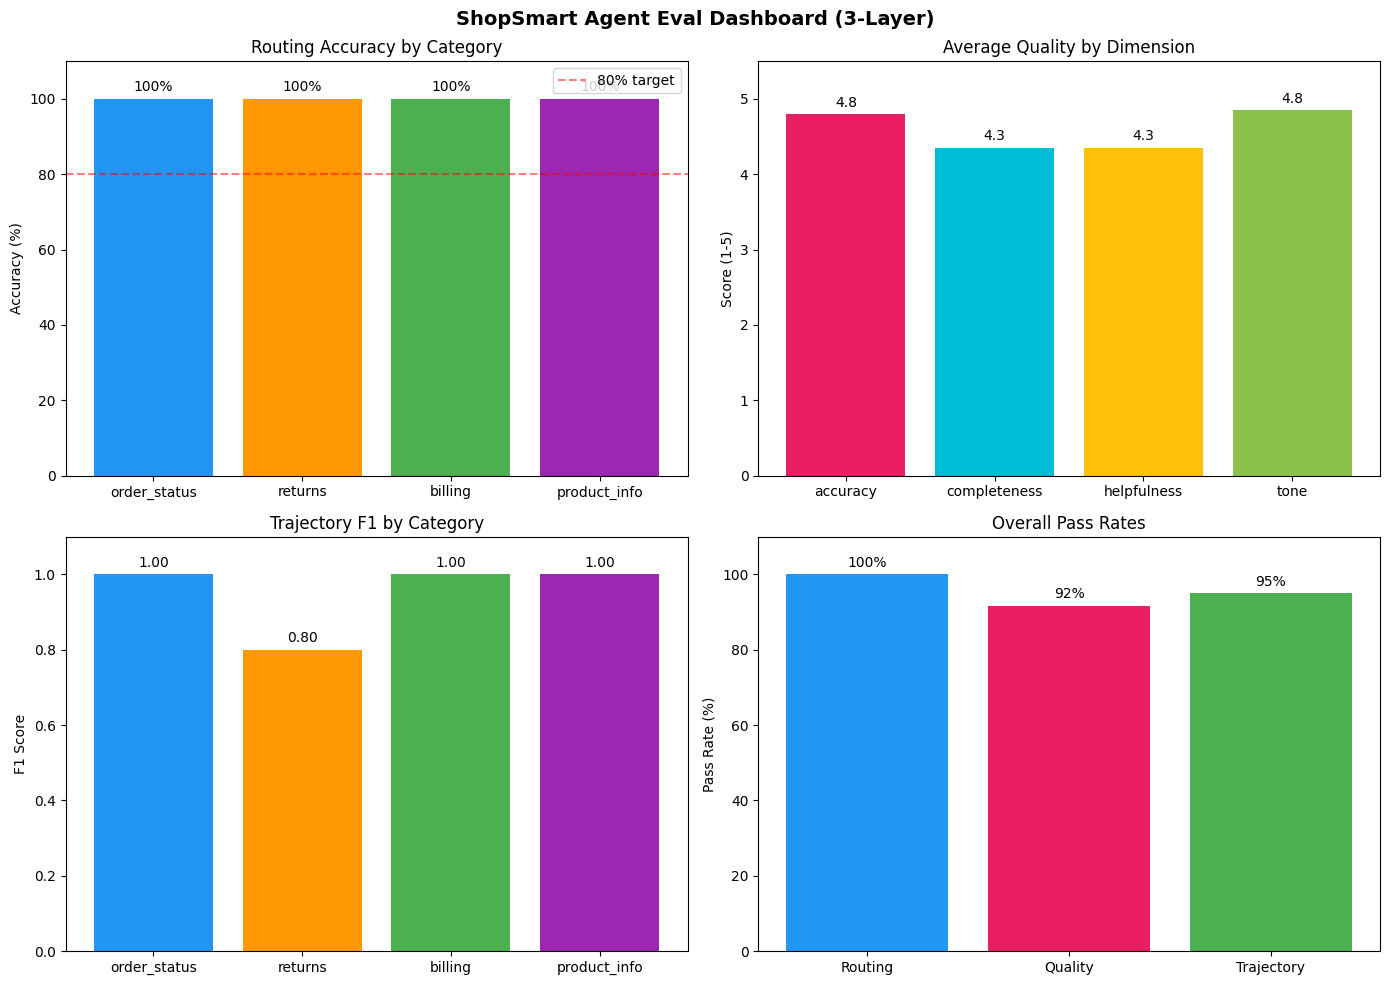

In [17]:
# --- Matplotlib Dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Routing accuracy per category
axes[0,0].bar(categories, [cat_routing[c] for c in categories], color=['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'])
axes[0,0].set_title('Routing Accuracy by Category')
axes[0,0].set_ylabel('Accuracy (%)')
axes[0,0].set_ylim(0, 110)
axes[0,0].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% target')
axes[0,0].legend()
for i, v in enumerate([cat_routing[c] for c in categories]):
    axes[0,0].text(i, v + 2, f'{v:.0f}%', ha='center')

# Top-right: Quality scores per dimension (average across all tests)
dims = ['accuracy', 'completeness', 'helpfulness', 'tone']
dim_avgs = [sum(q.get(d, 3) for q in quality_results)/len(quality_results) for d in dims]
axes[0,1].bar(dims, dim_avgs, color=['#E91E63', '#00BCD4', '#FFC107', '#8BC34A'])
axes[0,1].set_title('Average Quality by Dimension')
axes[0,1].set_ylabel('Score (1-5)')
axes[0,1].set_ylim(0, 5.5)
for i, v in enumerate(dim_avgs):
    axes[0,1].text(i, v + 0.1, f'{v:.1f}', ha='center')

# Bottom-left: Trajectory F1 per category
axes[1,0].bar(categories, [cat_traj[c] for c in categories], color=['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'])
axes[1,0].set_title('Trajectory F1 by Category')
axes[1,0].set_ylabel('F1 Score')
axes[1,0].set_ylim(0, 1.1)
for i, v in enumerate([cat_traj[c] for c in categories]):
    axes[1,0].text(i, v + 0.02, f'{v:.2f}', ha='center')

# Bottom-right: Overall pass rates
overall_routing = sum(1 for r in routing_results if r['correct']) / len(routing_results) * 100
overall_quality = sum(q['total'] for q in quality_results) / len(quality_results) / 20 * 100
overall_traj = sum(1 for t in trajectory_results if t['pass']) / len(trajectory_results) * 100
bars = axes[1,1].bar(['Routing', 'Quality', 'Trajectory'],
                      [overall_routing, overall_quality, overall_traj],
                      color=['#2196F3', '#E91E63', '#4CAF50'])
axes[1,1].set_title('Overall Pass Rates')
axes[1,1].set_ylabel('Pass Rate (%)')
axes[1,1].set_ylim(0, 110)
for bar, v in zip(bars, [overall_routing, overall_quality, overall_traj]):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center')

plt.suptitle('ShopSmart Agent Eval Dashboard (3-Layer)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Eval-Driven Improvement: Fix the Weakest Link

The dashboard revealed which category is weakest. Let's improve its handler prompt and re-evaluate.

In [18]:
# --- Identify and Improve Weakest Category ---
print(f"Weakest category: {weakest_cat}")
print(f"Current routing accuracy: {cat_routing[weakest_cat]:.0f}%")
print(f"Current quality: {cat_quality[weakest_cat]:.1f}/20")
print(f"Current trajectory F1: {cat_traj[weakest_cat]:.2f}")

# Get the failed test cases for this category
weak_tests = [(i, TEST_DATASET[i]) for i in range(len(TEST_DATASET))
              if TEST_DATASET[i]["expected_category"] == weakest_cat
              and (not routing_results[i]["correct"] or quality_results[i]["total"] < 15)]

print(f"\nFailed/weak test cases ({len(weak_tests)}):")
for idx, test in weak_tests:
    print(f"  {test['id']}: {test['query'][:60]}")
    print(f"    Routing: {'\u2705' if routing_results[idx]['correct'] else '\u274c'} | Quality: {quality_results[idx]['total']}/20")

Weakest category: order_status
Current routing accuracy: 100%
Current quality: 19.4/20
Current trajectory F1: 1.00

Failed/weak test cases (0):


In [19]:
# --- Re-run Eval on Weakest Category After Analysis ---
# Note: In a real workflow, you'd modify the handler prompt, rebuild the graph,
# and re-run. Here we demonstrate the PATTERN of eval-driven improvement.

print("Eval-Driven Improvement Workflow:")
print("=" * 60)
print("1. Dashboard identifies weakest category")
print(f"2. Analysis reveals {len(weak_tests)} failed/weak cases")
print("3. Improve handler prompt (add missing context, better instructions)")
print("4. Re-run eval suite on that category's test cases")
print("5. Compare before/after metrics")
print("6. Repeat until all categories meet threshold (80% routing, 15/20 quality)")
print("\nThis is the core eval loop that turns 'it seems to work' into 'we can prove it works'.")

Eval-Driven Improvement Workflow:
1. Dashboard identifies weakest category
2. Analysis reveals 0 failed/weak cases
3. Improve handler prompt (add missing context, better instructions)
4. Re-run eval suite on that category's test cases
5. Compare before/after metrics
6. Repeat until all categories meet threshold (80% routing, 15/20 quality)

This is the core eval loop that turns 'it seems to work' into 'we can prove it works'.


## pass@k: Measuring Consistency

Run each test **3 times**. Does the agent give the same correct answer each time? `pass@1` = single-try accuracy. `pass@3` = at least 1 of 3 tries correct.

In [20]:
# --- pass@k Demo (subset of 5 tests for speed) ---
K = 3
subset = TEST_DATASET[:5]  # First 5 tests

print(f"pass@{K} Consistency Test (5 test cases x {K} trials)")
print("=" * 60)

pass_at_1_count = 0
pass_at_k_count = 0

for test in subset:
    trials = []
    for trial in range(K):
        result = compiled_agent.invoke({"customer_query": test["query"]})
        correct = evaluate_routing(test["expected_category"], result["category"])
        trials.append(correct)

    pass_1 = trials[0]  # First try
    pass_k = any(trials)  # At least 1 of K correct
    if pass_1: pass_at_1_count += 1
    if pass_k: pass_at_k_count += 1

    print(f"{test['id']}: trials={trials} | pass@1={'\u2705' if pass_1 else '\u274c'} | pass@{K}={'\u2705' if pass_k else '\u274c'}")

print(f"\npass@1: {pass_at_1_count}/{len(subset)} ({pass_at_1_count/len(subset)*100:.0f}%)")
print(f"pass@{K}: {pass_at_k_count}/{len(subset)} ({pass_at_k_count/len(subset)*100:.0f}%)")
print(f"\nInterpretation: pass@{K} >= pass@1. If pass@{K} >> pass@1, the agent is inconsistent (non-deterministic).")

pass@3 Consistency Test (5 test cases x 3 trials)
T01: trials=[True, True, True] | pass@1=✅ | pass@3=✅
T02: trials=[True, True, True] | pass@1=✅ | pass@3=✅
T03: trials=[True, True, True] | pass@1=✅ | pass@3=✅
T04: trials=[True, True, True] | pass@1=✅ | pass@3=✅
T05: trials=[True, True, True] | pass@1=✅ | pass@3=✅

pass@1: 5/5 (100%)
pass@3: 5/5 (100%)

Interpretation: pass@3 >= pass@1. If pass@3 >> pass@1, the agent is inconsistent (non-deterministic).


How OpenAI's Eval Framework Handles This

OpenAI provides a formal evaluation framework with JSONL datasets, YAML configs, and model-graded evals. Here's how the same evaluation would look in their ecosystem.

In [21]:
# --- OpenAI Eval Framework Equivalents (REFERENCE CODE) ---

OPENAI_EVAL_REFERENCE = '''
# ============================================================
# OpenAI Evals Framework Approach (reference, not runnable)
# ============================================================

# 1. DATASET FORMAT: JSONL with input + ideal
# shopsmart_eval.jsonl:
# {"input": [{"role": "user", "content": "Where is ORD-1001?"}], "ideal": "In Transit, 2 days"}
# {"input": [{"role": "user", "content": "Return policy?"}], "ideal": "7-day for electronics"}

# 2. EVAL CONFIG: YAML
# shopsmart_eval.yaml:
# id: shopsmart.support.quality
# description: Evaluate ShopSmart support agent
# metrics: [accuracy]
# args:
#   data_path: shopsmart_eval.jsonl
#   grading_type: model_graded

# 3. MODEL-GRADED EVAL: GPT-4 as judge
# The grading prompt evaluates output against ideal answer
# Returns: {"reason": "...", "score": 0.0-1.0, "pass": true/false}

# 4. RUN: oaieval gpt-4o-mini shopsmart.support.quality --max_samples 20

# 5. REGRESSION DETECTION: Compare two runs
# Run baseline: oaieval gpt-4o-mini eval_v1 > baseline.jsonl
# Run candidate: oaieval gpt-4o-mini eval_v2 > candidate.jsonl
# Compare: did accuracy improve or regress?
'''

print("OpenAI Eval Framework Comparison:")
print("  Dataset: JSONL (input + ideal) vs Python dicts (this lab)")
print("  Grading: Model-graded via oaieval vs Custom Python + LLM-as-Judge")
print("  Trajectory: Not built-in vs Custom tool tracking (this lab)")
print("  Regression: Built-in baseline comparison vs Manual before/after")
print("  Dashboard: OpenAI Evals platform vs Matplotlib (this lab)")

OpenAI Eval Framework Comparison:
  Dataset: JSONL (input + ideal) vs Python dicts (this lab)
  Grading: Model-graded via oaieval vs Custom Python + LLM-as-Judge
  Trajectory: Not built-in vs Custom tool tracking (this lab)
  Regression: Built-in baseline comparison vs Manual before/after
  Dashboard: OpenAI Evals platform vs Matplotlib (this lab)


## The 3-Layer Eval Hierarchy: Summary

| Layer | What | How | Metric |
|-------|------|-----|--------|
| **Layer 1: LLM Eval** | Single-turn response quality | LLM-as-Judge with rubric | accuracy, completeness, helpfulness, tone (1-5) |
| **Layer 2: RAG Eval** | Retrieval + generation | RAGAS metrics | faithfulness, answer relevancy (Lab 20) |
| **Layer 3: Agent Eval** | Multi-step trajectories | Tool tracking + pass@k | routing accuracy, F1, consistency |

## Conclusion

In this lab, we built a **3-layer evaluation suite** for ShopSmart's support agent:
- **Grader 1 (Routing):** Deterministic exact-match — did the agent route correctly?
- **Grader 2 (Quality):** LLM-as-Judge with 4-dimension rubric — is the response good?
- **Grader 3 (Trajectory):** Keyword contains-check — did the response use the right data?
- **Dashboard:** 4-panel Matplotlib visualization of all metrics
- **Eval-driven improvement:** Identify weakest category → improve → re-evaluate
- **pass@k:** Measure consistency across multiple trials

